In [1]:
import heapq
import random
import math
import matplotlib.pyplot as plt

In [2]:
class Problem:
    """
    A class used to represent the problem state for the n-queens domain.
    """
    def __init__(self,n):
        """
        Constructs the n-queens problem.
        param n: the number of queens / nxn board
        """
        self.n = n
    
    def initial_state(self):
        """
        Calls States Constructor to define the starting board of problem size n.
        :return: 
        """
        return State(n=self.n)
    
    def successor_function(self,state):
        """
        Creates a list of all possible successor states from a board state.
        :param state: A state object.
        :return: list of state objects
        """
        successors = []
        n = len(state.positions)
        for row in range(n):
            for column in range(n):
                if column != state.positions[row]:
                    new_state = state.move_queen(row,column)
                    successors.append(new_state)
        return successors
        
    def goal_test(self,state):
        """
        End goal, tests for zero attacking queens
        :param state: A state object.
        :return: Boolean. True if no conflicts, false otherwise.
        """
        if self.objective_function_value(state) == 0:
            return True
        else:
            return False
    
    def objective_function_value(self,state):
        """
        Determines the objective value of a given board state.
        The objective value is the amount of queens that can attack each other.
        :param state: A state object.
        :return: An integer.
        """
        attacks = 0
        board = state.positions
        n = len(board)
        
        for row in range(n):
            for j in range(row+1,n):
                if board[row] == board[j]:
                    attacks += 1
                if abs(board[row] - board[j]) == abs(row - j):
                    attacks += 1
        
        return attacks

In [3]:
class State:
    """
    A class used to represent the state of an n-queens board.
    Queen positions are represented as a list where each element represents a row,
    and the integer value represents the column.
    """
    def __init__(self, positions=None, n=None):
        """
        Constructs the n-queens board state. Randomly generates starting point
        if none exists.
        :param positions: List of positions of the queens.
        :param n: Integer. Number of queens / board dimension.
        """
        if positions is not None:
            self.positions = positions
        else:
            self.positions = list(range(n))
            for i in range(n):
                self.positions[i] = random.randint(0,n-1)
    
    def move_queen(self, row, column):
        """
        Used to generate successors. Creates a copy of the board state
        and returns the new state with moved queens.
        :param row: Row who's queen to be moved.
        :param column: Column of the row queen to be moved.
        :return: A new state object.
        """
        new_positions = self.positions.copy()
        new_positions[row] = column
        return State(positions=new_positions)
    
    def __repr__(self):
        """
        String representation of the board state.
        :return: String of integers.
        """
        return f"{self.positions}"

def display_board(state,problem):
    """
    Helper function to display the board.
    :param state: A board state object.
    :return: Nothing.
    """
    n = len(state.positions)
    
    print("Final: ", state.positions)
    print("Final OBJ Value: ", problem.objective_function_value(state))
    
    for row in range(n):
        for column in range(n):
            if state.positions[row] == column:
                print("[Q]",end="")
            else:
                print("[ ]", end="")
        print()

### Basic Hill Climbing

In [4]:
def hill_climbing(problem):
    """
    Runs the hill climbing algorithm on the given n-queens problem.
    Generates successors and greedily uses the lowest objective function.
    :param problem: n-queens problem object.
    :return: The board state with the lowest objective value.
    """
    current = problem.initial_state()
    
    iterations = 0

    while True:
        current_objective_value = problem.objective_function_value(current)
        successors = problem.successor_function(current)
        
        neighbor = min(successors, key=problem.objective_function_value)
        next_objective_value = problem.objective_function_value(neighbor)
        
        if next_objective_value >= current_objective_value:
            break
        
        current = neighbor
        iterations += 1
    
    final_obj = problem.objective_function_value(current)
    
    return current, iterations, final_obj

In [5]:
hill_climb_runs = []
for i in range(10000):
    hill = Problem(8)
    hill_climb_runs.append(hill_climbing(hill)[1:])

Converges to Solution State: 1454 / 10000.


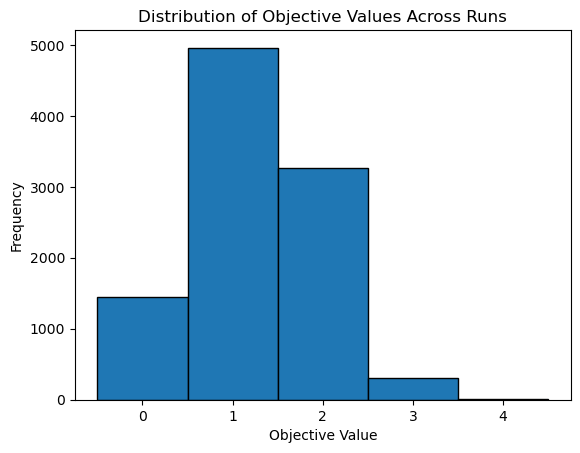

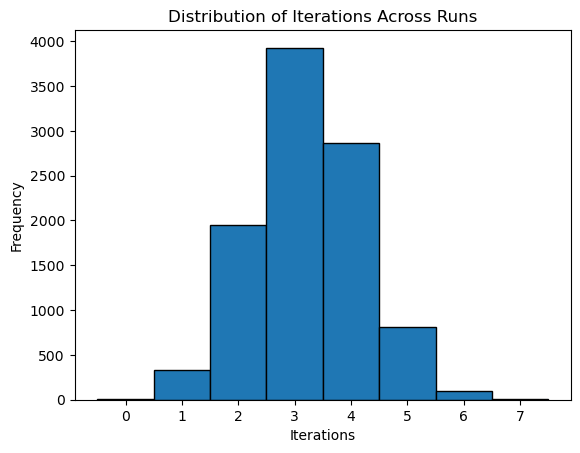

In [6]:
iterations, objective_vals = zip(*hill_climb_runs)
converges = objective_vals.count(0)
print(f'Converges to Solution State: {converges} / {len(hill_climb_runs)}.')

plt.hist(objective_vals, 
         bins=range(min(objective_vals), max(objective_vals) + 2),
         edgecolor='black',
         align='left')

plt.xticks(range(min(objective_vals), max(objective_vals) + 1))
plt.xlabel("Objective Value")
plt.ylabel("Frequency")
plt.title("Distribution of Objective Values Across Runs")
plt.show()

plt.hist(iterations, 
         bins=range(min(iterations), max(iterations) + 2),
         edgecolor='black',
         align='left')

plt.xticks(range(min(iterations), max(iterations) + 1))
plt.xlabel("Iterations")
plt.ylabel("Frequency")
plt.title("Distribution of Iterations Across Runs")

plt.show()

plt.show()

### Random Restart Hill Climbing

In [7]:
def random_restart(problem):
    """
    Runs the random restart hill climbing algorithm on the given n-queens problem.
    If hill climbing ever converges to a non goal-state solution, it will restart with
    a new random board state.
    :param problem: A n-queens problem object.
    :return: The board state with the lowest objective value.
    """
    restarts = -1
    while True:
        restarts += 1
        current = problem.initial_state()
    
        while True:
            current_objective_value = problem.objective_function_value(current)
            successors = problem.successor_function(current)
            
            neighbor = min(successors, key=problem.objective_function_value)
            next_objective_value = problem.objective_function_value(neighbor)
            
            if next_objective_value >= current_objective_value:
                break
            
            current = neighbor
            
        current_objective_value = problem.objective_function_value(current)
        if current_objective_value == 0:
            break
    
    return current, restarts

In [8]:
runs_restart = []
for i in range(10000):
    restart = Problem(8)
    runs_restart.append(random_restart(restart)[1])

zero_restarts = runs_restart.count(0)

In [9]:
max_restarts = max(runs_restart)

Solution found in first run: 1415 / 10000
Maximum Restarts: 60


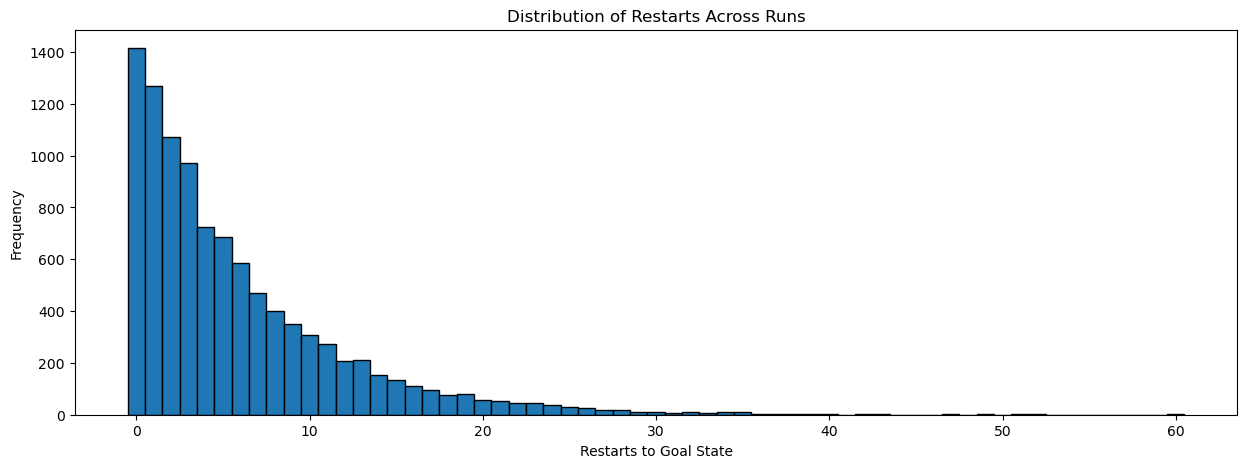

In [10]:
plt.figure(figsize=(15,5))
plt.hist(runs_restart, 
         bins=range(min(runs_restart), max(runs_restart) + 2),
         edgecolor='black',
         align='left')

plt.xlabel("Restarts to Goal State")
plt.ylabel("Frequency")
plt.title("Distribution of Restarts Across Runs")

print(f'Solution found in first run: {zero_restarts} / {len(runs_restart)}')
print(f'Maximum Restarts: {max_restarts}')
plt.show()

### Simulated Annealing

In [11]:
T0 = 1
steps = 400
alpha = 0.95

In [12]:
linear_schedule = []
for t in range(steps):
    T = T0 * (1 - t/steps)
    if T < 0:
        T = 0
    linear_schedule.append(T)

In [13]:
exp_schedule = []
T = T0
for t in range(steps):
    exp_schedule.append(T)
    T = T * alpha

In [14]:
log_schedule = []
for t in range(1, steps + 1):
    T = T0 / math.log(t + 1)
    log_schedule.append(T)

In [15]:
quadratic_schedule = []
for t in range(steps):
    fraction = 1 - (t / steps)
    T = T0 * (fraction ** 2)
    quadratic_schedule.append(T)

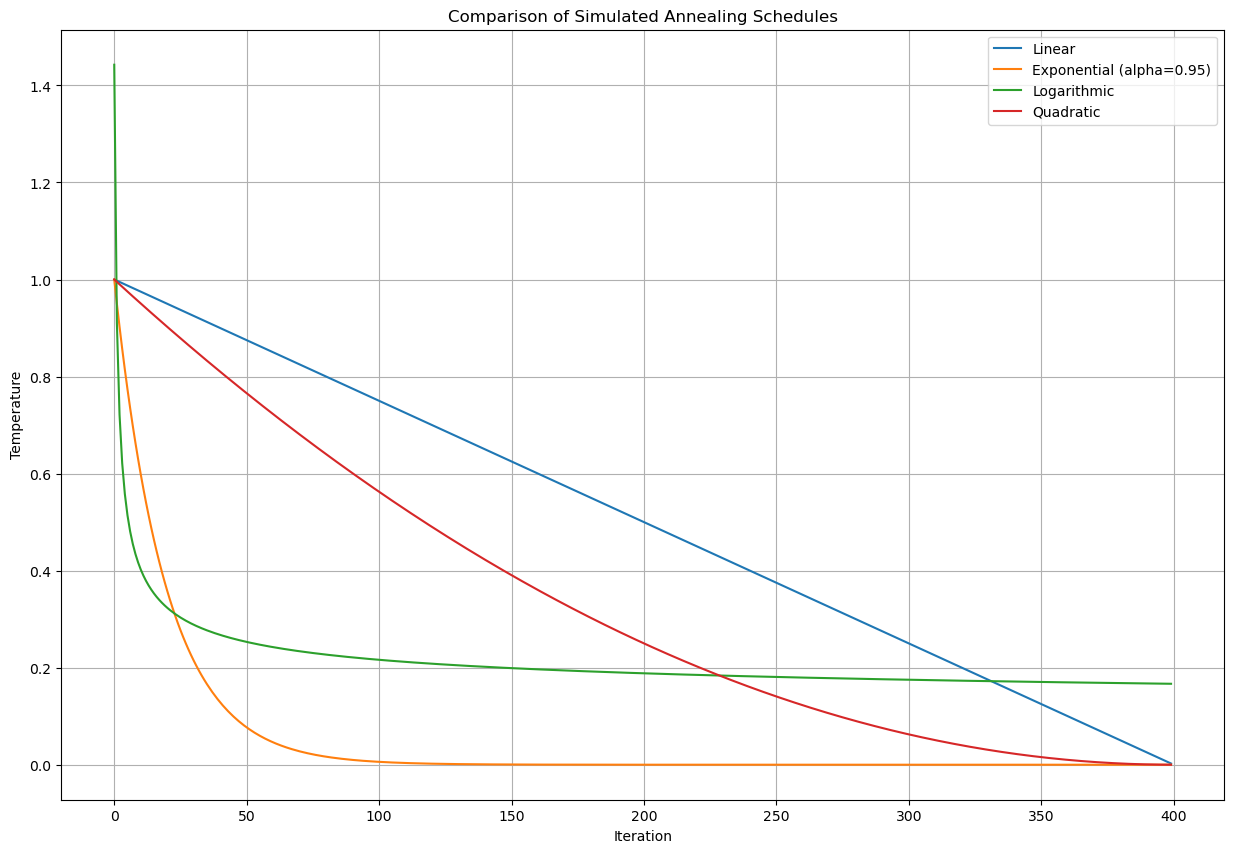

In [16]:
plt.figure(figsize=(15,10))

plt.plot(linear_schedule, label="Linear")
plt.plot(exp_schedule, label="Exponential (alpha=0.95)")
plt.plot(log_schedule, label="Logarithmic")
plt.plot(quadratic_schedule, label="Quadratic")

plt.xlabel("Iteration")
plt.ylabel("Temperature")
plt.title("Comparison of Simulated Annealing Schedules")
plt.legend()
plt.grid(True)

plt.show()

In [17]:
def simulated_annealing(problem,schedule):
    """
    Runs the simulated annealing algorithm on the given n-queens problem.
    Uses a temperature schedule as a decision variable on whether to accept worse outcomes.
    :param problem: An n-queens problem object.
    :param schedule: A list of floats (temperatures) representing the schedule.
    :return: The board state with the lowest objective value.
    """
    current = problem.initial_state()
    for t in range(len(schedule)):
        T = schedule[t]
        if T <= 0:
            break
        
        successors = problem.successor_function(current)
        next_state = random.choice(successors)
        
        delta_e = problem.objective_function_value(next_state) - problem.objective_function_value(current)
        
        if delta_e <= 0 or random.random() < math.exp(-delta_e / T):
            current = next_state
        
        obj = problem.objective_function_value(current)
        
    return current, obj

In [18]:
anneal_solutions = []
for i in range(10000):
    anneal = Problem(8)
    anneal_solutions.append(simulated_annealing(anneal, log_schedule)[1])

Solution found in first run: 4652 / 10000


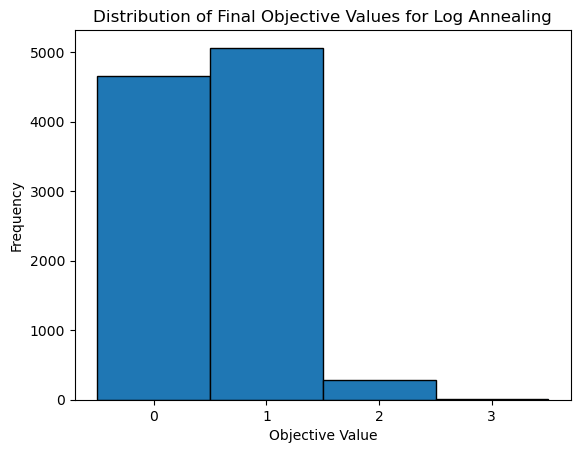

In [19]:
print(f'Solution found in first run: {anneal_solutions.count(0)} / {len(anneal_solutions)}')

plt.hist(anneal_solutions, 
         bins=range(min(anneal_solutions), max(anneal_solutions) + 2),
         edgecolor='black',
         align='left')

plt.xticks(range(min(anneal_solutions), max(anneal_solutions) + 1))
plt.xlabel("Objective Value")
plt.ylabel("Frequency")
plt.title("Distribution of Final Objective Values for Log Annealing")

plt.show()

In [20]:
anneal_solutions = []
for i in range(10000):
    anneal = Problem(8)
    anneal_solutions.append(simulated_annealing(anneal, linear_schedule)[1])

Solution found in first run: 2661 / 10000


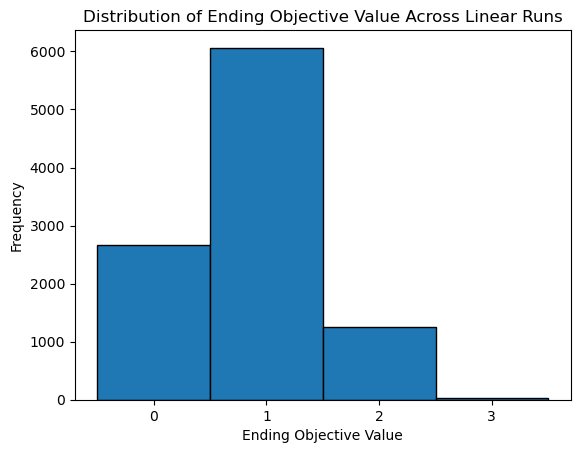

In [21]:
print(f'Solution found in first run: {anneal_solutions.count(0)} / {len(anneal_solutions)}')

plt.hist(anneal_solutions, 
         bins=range(min(anneal_solutions), max(anneal_solutions) + 2),
         edgecolor='black',
         align='left')

plt.xticks(range(min(anneal_solutions), max(anneal_solutions) + 1))
plt.xlabel("Ending Objective Value")
plt.ylabel("Frequency")
plt.title("Distribution of Ending Objective Value Across Linear Runs")

plt.show()

### Local Beam Search

In [22]:
def local_beam_search(problem, k, max_iterations=1000):
    """
    Runs the local beam search algorithm on the given n-queens problem.
    Generates successors to each k state and picks the best k successors.
    :param problem: A problem object of the n-queens problem.
    :param k: Integer, number of states
    :return: State object, final board.
    """
    k_states = [None] * k
    iterations = 0
    
    for i in range(k):
        k_states[i] = problem.initial_state()
    
    while iterations < max_iterations:
        iterations += 1
        successors = []
        for i in range(k):
            successors.extend(problem.successor_function(k_states[i]))

        next_states = heapq.nsmallest(k, successors, key=problem.objective_function_value)
        
        next_obj_values = [problem.objective_function_value(i) for i in next_states]
        k_states_obj_values = [problem.objective_function_value(i) for i in k_states]
        
        if next_obj_values == k_states_obj_values:
            return next_states[0], problem.objective_function_value(next_states[0])
        
        k_states = next_states
        
        for i in range(k):
            if problem.goal_test(k_states[i]):
                return k_states[i], problem.objective_function_value(k_states[i])
        
    best = min(k_states, key=problem.objective_function_value)
    return best, problem.objective_function_value(best)

In [23]:
beam_solutions = []
for i in range(10000):
    beam = Problem(8)
    beam_solutions.append(local_beam_search(beam,8)[1])

Solutions found: 6703 / 10000


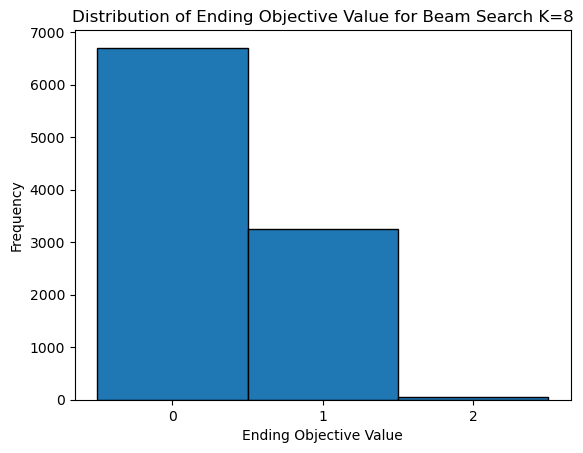

In [24]:
print(f'Solutions found: {beam_solutions.count(0)} / {len(beam_solutions)}')
plt.hist(beam_solutions, 
         bins=range(min(beam_solutions), max(beam_solutions) + 2),
         edgecolor='black',
         align='left')

plt.xticks(range(min(beam_solutions), max(beam_solutions) + 1))
plt.xlabel("Ending Objective Value")
plt.ylabel("Frequency")
plt.title("Distribution of Ending Objective Value for Beam Search K=8")

plt.show()

### Combination Approach

In [25]:
def annealing_beam(problem,k, schedule, max_restarts=50):
    '''
    Combines local beam search, simulated annealing, and random restart. 
    :param problem: A problem object of the n-queens problem.
    :param k: k-states to examine
    :param schedule: list containing the annealing schedule
    :param max_restarts: integer limiting the number of restarts
    :return: Best overall State, number of restarts
    '''
    restarts = -1
    
    for i in range(max_restarts):
        restarts += 1
        
        k_states = [None] * k
        for i in range(k):
            k_states[i] = problem.initial_state()
        
        best_overall = min(k_states, key=problem.objective_function_value)
        
        for t in range(len(schedule)):
            T = schedule[t]
            if T <= 0:
                break
            
            successors = []
            for state in k_states:
                successors.extend(problem.successor_function(state))
            
            next_states = []
            
            current_best = min(k_states, key=problem.objective_function_value)
            best_value = problem.objective_function_value(current_best)
            
            for i in range(len(successors)):
                successor_value = problem.objective_function_value(successors[i])
                
                delta_e = successor_value - best_value
                
                if delta_e <= 0:
                    next_states.append(successors[i])
                else:
                    if random.random() < math.exp(-delta_e / T):
                        next_states.append(successors[i])
                
                if len(next_states) == k:
                    break
            
            if not next_states:
                break
            
            k_states = next_states
            
            current_best = min(k_states, key=problem.objective_function_value)
            
            if problem.goal_test(current_best):
                return current_best, restarts
            
            if problem.objective_function_value(current_best) < problem.objective_function_value(best_overall):
                best_overall = current_best
    
    return best_overall, restarts

In [26]:
beneal_restarts = []
beneal_final_objs = []

for i in range(1000):
    beneal = Problem(8)
    final_state, restarts = annealing_beam(beneal,4,log_schedule,max_restarts=30)
    
    beneal_restarts.append(restarts)
    beneal_final_objs.append(beneal.objective_function_value(final_state))

Solutions found: 1000 / 1000


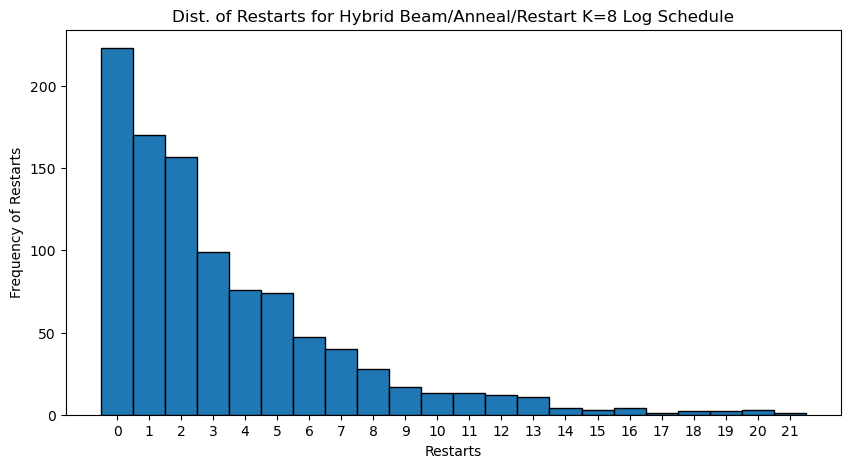

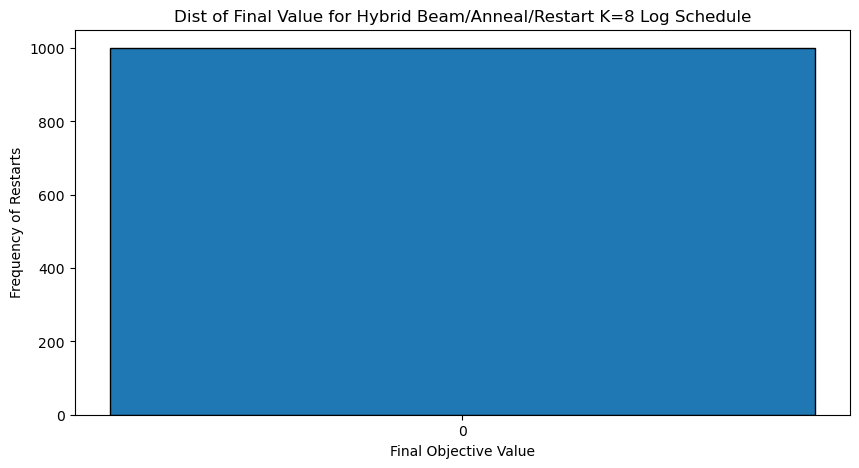

In [27]:
print(f'Solutions found: {beneal_final_objs.count(0)} / 1000')

plt.figure(figsize=(10,5))
plt.hist(beneal_restarts, 
         bins=range(min(beneal_restarts), max(beneal_restarts) + 2),
         edgecolor='black',
         align='left')

plt.xticks(range(min(beneal_restarts), max(beneal_restarts) + 1))
plt.xlabel("Restarts")
plt.ylabel("Frequency of Restarts")
plt.title("Dist. of Restarts for Hybrid Beam/Anneal/Restart K=8 Log Schedule")
plt.show()

plt.figure(figsize=(10,5))
plt.hist(beneal_final_objs, 
         bins=range(min(beneal_final_objs), max(beneal_final_objs) + 2),
         edgecolor='black',
         align='left')
plt.xticks(range(min(beneal_final_objs), max(beneal_final_objs) + 1))
plt.xlabel("Final Objective Value")
plt.ylabel("Frequency of Restarts")
plt.title("Dist of Final Value for Hybrid Beam/Anneal/Restart K=8 Log Schedule")

plt.show()